In [1]:
import glob
import os
import json
import copy
from importlib import reload
import tifffile as tf
import numpy as np
import pandas as pd
import networkx as nx
from scipy import ndimage

import matplotlib.pyplot as plt
import gudhi as gd

import matplotlib as mpl
import utils

# List of color-blind friendly colors
wong = ['#e69f00','#56b4e9','#757575','#009e73','#f0e442','#999999', '#0072b2','#d55e00','#cc79a7', '#cccccc']

In [2]:
filesrcs = sorted(glob.glob(os.pardir + os.sep + 'data' + os.sep + '*' + os.sep))
filesrcs

['../data/leaf_25d_WT2/',
 '../data/leaf_25d_WT4/',
 '../data/leaf_25d_WT4_random/',
 '../data/sepal/',
 '../data/sepal_random/']

In [3]:
sidx = 0

src = filesrcs[sidx]
dst = os.pardir + os.sep + 'results' + os.sep + os.path.dirname(src).split(os.sep)[-1] + os.sep
print(dst)

../results/leaf_25d_WT2/


In [4]:
tifffiles = sorted(glob.glob(src + '*.tif*'))
print(tifffiles)

tidx = 0
bname, _ = os.path.splitext(os.path.split(tifffiles[tidx])[1])
print(tidx, bname, sep='\t')

# Load the raw image
img = tf.imread(tifffiles[tidx])

# Largest cell label
maxcell = img.max()

# bounding boxes for each cell
css = ndimage.find_objects(img)

['../data/leaf_25d_WT2/segmentation.tiff']
0	segmentation


In [16]:
datafile = src + bname + '_extended_metadata.csv'
print(datafile)
data = pd.read_csv(datafile).set_index('Label')
data = data[data['true_cell']]

foo = ['#f0f0f0'] + np.tile(wong, len(data)+2).tolist()
cmap = mpl.colors.ListedColormap(foo[:len(data)+1])
imgpos = dict(zip(range(1,len(data)+1), data[['centerX', 'centerY']].to_numpy())) 
gpos = dict(zip(range(1,len(data)+1), data[['extcenterX', 'extcenterY']].to_numpy()))

print(data.shape)
data.head()

../data/leaf_25d_WT2/segmentation_extended_metadata.csv
(547, 11)


,true_cell,extcenterX,extcenterY,centerX,centerY,perimeter,area,ch_perimeter,ch_area,pconvexity,aconvexity
Label,,,,,,,,,,,
1,True,-0.5,-0.500000,38.982724,7.927846,183.840620,984.0,171.707897,1408.0,0.934004,0.698864
2,True,-0.5,74.931299,38.788442,74.931299,530.717821,7700.0,405.851804,10657.5,0.764722,0.722496
3,True,-0.5,76.095436,4.419087,76.095436,65.213203,241.0,67.754109,254.0,1.038963,0.948819
4,True,-0.5,278.390461,36.087555,278.390461,764.587878,10462.0,574.828309,16280.5,0.751815,0.642609
5,True,-0.5,383.235363,54.063793,383.235363,418.534055,6866.0,375.432179,9260.5,0.897017,0.741429


In [17]:
lens = data['area'].copy()

mimg = img.copy().astype(float)
for idx in data[data['true_cell']].index:
    mimg[css[idx - 1]][ mimg[css[idx-1]] == idx ] = lens.loc[idx]

In [23]:
threshold = 75000
data[lens > threshold].head()

,true_cell,extcenterX,extcenterY,centerX,centerY,perimeter,area,ch_perimeter,ch_area,pconvexity,aconvexity
Label,,,,,,,,,,,
23,True,-0.500000,1520.726122,338.701662,1520.726122,5130.388453,125180.0,2021.130967,245716.5,0.393953,0.509449
35,True,-0.500000,2598.513118,288.104791,2598.513118,4457.746750,98835.0,1820.350428,219082.5,0.408357,0.451131
48,True,311.075709,-0.500000,311.075709,147.827766,2724.951586,79119.0,1389.414020,122023.5,0.509886,0.648391
58,True,360.794690,789.829436,360.794690,789.829436,4157.160964,103117.0,1718.979705,195023.0,0.413498,0.528743
109,True,729.620986,1593.457244,729.620986,1593.457244,3918.094947,98313.0,1668.156336,191766.5,0.425757,0.512670


## Set up a Euclidean distance transform

In [26]:
edt = ndimage.distance_transform_edt(mimg <= threshold)

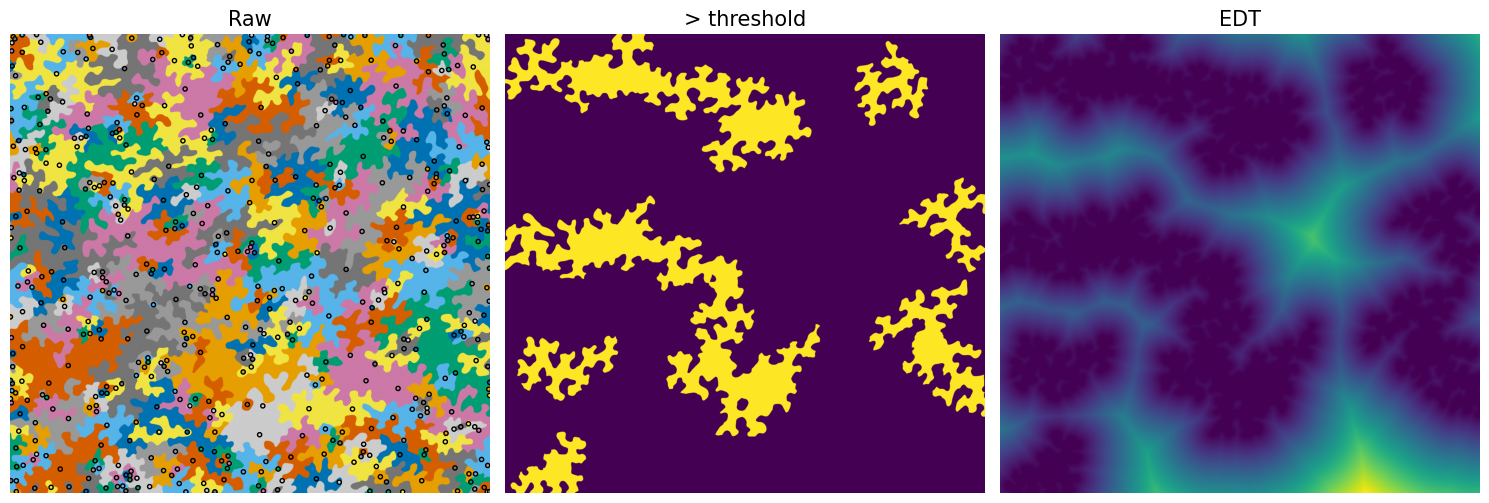

In [28]:
fig, ax = plt.subplots(1,3, figsize=(15,6), sharex=True, sharey=True); 
ax = np.atleast_1d(ax).ravel()
i = 0
ax[i].imshow(img, origin='lower', cmap=cmap, vmin=0)
ax[i].scatter(*data.loc[data['true_cell'], ['centerX','centerY']].T.to_numpy(), 
              marker='.', ec='k', c=data[data['true_cell']].index, cmap=cmap, vmin=0)
i += 1
ax[i].imshow(mimg > threshold, origin='lower', cmap='viridis', vmin=0)
i += 1
ax[i].imshow(edt, origin='lower', cmap='viridis', vmin=0)

titles = ['Raw', '> threshold', 'EDT']
for i in range(len(ax)):
    ax[i].axis('off')
    ax[i].set_title(titles[i], fontsize=15)
fig.tight_layout()

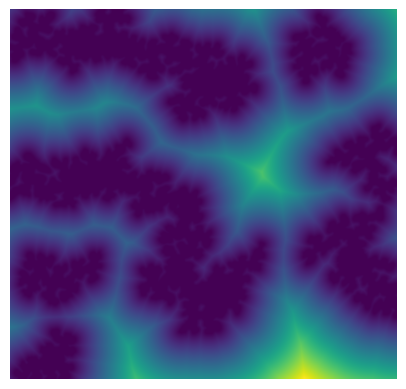

In [78]:
zedt = ndimage.zoom(edt, zoom=0.5)
zedt[zedt < 1 ] = 0
plt.imshow(zedt, origin='lower', vmax=edt.max())
plt.axis('off');

## Using gudhi to compute level set persistence

https://gudhi.inria.fr/python/latest/cubical_complex_ref.html

In [69]:
cc = gd.CubicalComplex(top_dimensional_cells = zedt )
pers = cc.persistence(homology_coeff_field=2, min_persistence=1e-15)
print('Found',len(pers),'topological elements')

Found 2860 topological elements


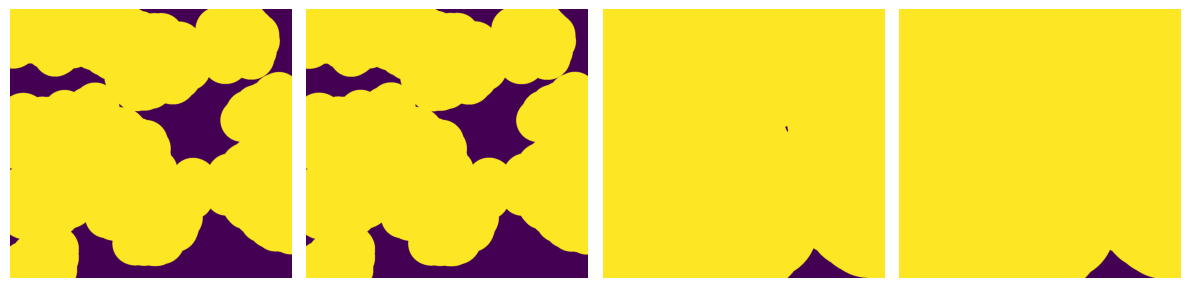

In [70]:
p = 0
fig, ax = plt.subplots(1,4, figsize=(12,6), sharex=True, sharey=True); 
ax = np.atleast_1d(ax).ravel(); i = 0

ax[i].imshow(zedt < pers[p][1][0]-1, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt <= pers[p][1][0]+1, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt < pers[p][1][1]-10, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt <= pers[p][1][1]+1, origin='lower', vmin=0)
for i in range(len(ax)):
    ax[i].axis('off')
    #ax[i].set_title(titles[i], fontsize=15)
fig.tight_layout()

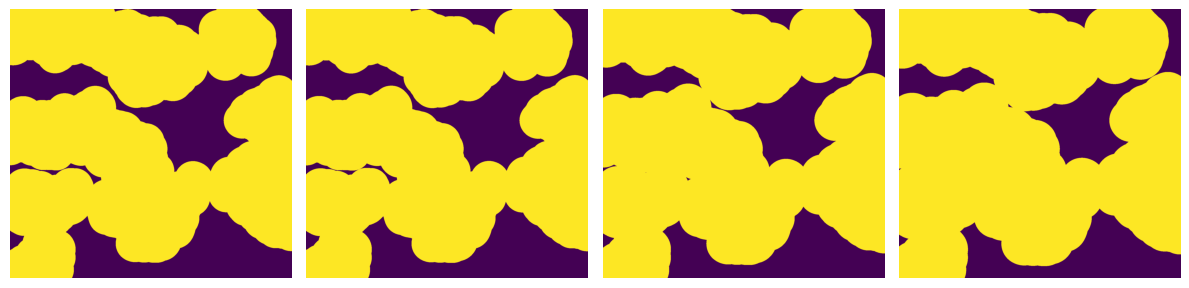

In [71]:
p = 1
fig, ax = plt.subplots(1,4, figsize=(12,6), sharex=True, sharey=True); 
ax = np.atleast_1d(ax).ravel(); i = 0

ax[i].imshow(zedt < pers[p][1][0]-1, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt <= pers[p][1][0]+1, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt < pers[p][1][1]-10, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt <= pers[p][1][1]+1, origin='lower', vmin=0)
for i in range(len(ax)):
    ax[i].axis('off')
    #ax[i].set_title(titles[i], fontsize=15)
fig.tight_layout()

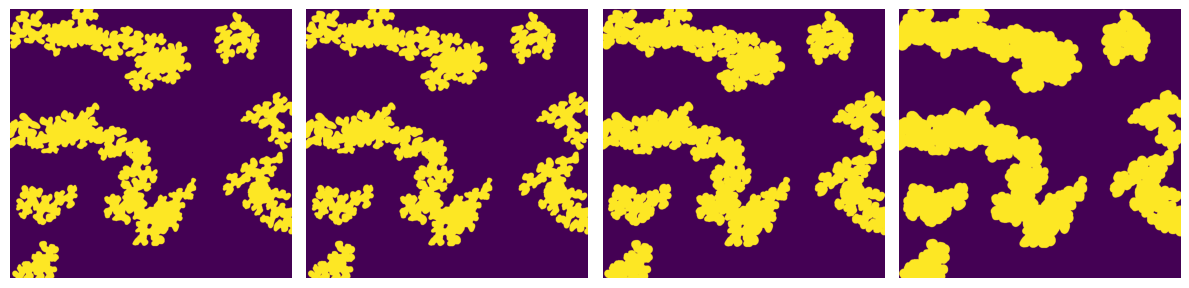

In [72]:
p = 10
fig, ax = plt.subplots(1,4, figsize=(12,6), sharex=True, sharey=True); 
ax = np.atleast_1d(ax).ravel(); i = 0

ax[i].imshow(zedt < pers[p][1][0]-1, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt <= pers[p][1][0]+1, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt < pers[p][1][1]-10, origin='lower', vmin=0)
i += 1
ax[i].imshow(zedt <= pers[p][1][1]+1, origin='lower', vmin=0)
for i in range(len(ax)):
    ax[i].axis('off')
    #ax[i].set_title(titles[i], fontsize=15)
fig.tight_layout()

In [79]:
def pers2numpy(pers):
    bd = np.zeros((len(pers), 3), dtype=float)
    for i in range(len(bd)):
        bd[i, 0] = pers[i][0]
        bd[i, 1:] = pers[i][1]
    return bd
npers = pd.DataFrame(pers2numpy(pers), columns=['dim','birth','death']).astype({'dim':int})
npers[npers['dim'] == 0]

,dim,birth,death
2853,0,0.0,inf
2854,0,0.0,209.513472
2855,0,0.0,156.587658
2856,0,0.0,152.819226
2857,0,0.0,152.486466
2858,0,0.0,95.202558
2859,0,0.0,23.826617


In [80]:
npers[npers['dim'] == 1]

,dim,birth,death
0,1,225.175603,513.153624
1,1,190.304876,223.673285
2,1,0.000000,32.040438
3,1,297.451266,327.628915
4,1,14.555210,36.595010
...,...,...,...
2848,1,22.615623,22.616066
2849,1,152.870433,152.870748
2850,1,24.369483,24.369769
2851,1,14.894157,14.894331


In [83]:
persfile = src + bname + '_levelset_persistence.json'
with open(persfile, 'w') as f:
    json.dump(pers,f)
    print('File', persfile,'written.')

File ../data/leaf_25d_WT2/segmentation_levelset_persistence.json written.
